                                                                                                by Maria 

# <center> Perceptron using Pytorch

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import torch
import torchvision
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from skimage.feature import hog
import time

In [2]:
print(f"PyTorch version: {torch.__version__}, CUDA version: {torch.version.cuda}")
print(f"torchvision version: {torchvision.__version__}")

PyTorch version: 2.5.0+cu124, CUDA version: 12.4
torchvision version: 0.20.0+cu124


Задание №4
1.  Знакомство с pytorch - познакомьтесь с документацией для pytorch
(https://pytorch.org/tutorials/beginner/basics/intro.html).
2. Вам необхоидимо создать простейший перцептрон с двумя слоями и обучить его
классифицировать элементы в датасете MNIST.
3. Сравните эти результаты с работой вашего собственного перцептрона и SVC.
Проаналзируйте результаты.

# Simple 2-Layer Perceptron using Pytorch

![img](./data/img/5th/i.webp)

In [59]:
def create_hog_features(images):
    hog_features = []
    for image in images:
        fd, hog_image = hog(image, orientations=8, pixels_per_cell=(3, 3),
                    cells_per_block=(1, 1), visualize=True, channel_axis=None)
        hog_features.append(fd)
    return np.array(hog_features)

In [61]:
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

In [62]:
X_train_hog = create_hog_features(train_dataset.data.numpy())
y_train = train_dataset.targets.numpy()

X_test_hog = create_hog_features(test_dataset.data.numpy())
y_test = test_dataset.targets.numpy()

In [63]:
X_train_hog_tensor = torch.FloatTensor(X_train_hog)
y_train_tensor = torch.LongTensor(y_train)
X_test_hog_tensor = torch.FloatTensor(X_test_hog)
y_test_tensor = torch.LongTensor(y_test)

In [64]:
train_tensor_dataset = torch.utils.data.TensorDataset(X_train_hog_tensor, y_train_tensor)
test_tensor_dataset = torch.utils.data.TensorDataset(X_test_hog_tensor, y_test_tensor)

In [66]:
train_loader = DataLoader(dataset=train_tensor_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_tensor_dataset, batch_size=batch_size, shuffle=False)

In [194]:
input_size = 648
hidden_size = 256 
num_classes = 10 
num_epochs = 15   
batch_size = 200   
learning_rate = 0.0008

Dropout (исключение) — метод регуляризации искусственных нейронных сетей.
(https://medium.com/analytics-vidhya/a-simple-introduction-to-dropout-regularization-with-code-5279489dda1e)

Он предназначен для уменьшения переобучения сети за счёт предотвращения сложных коадаптаций отдельных нейронов на тренировочных данных во время обучения.

Dropout исключает определённый процент (например, 30 %) случайных нейронов (находящихся как в скрытых, так и в видимых слоях) на разных итерациях (эпохах) во время обучения нейронной сети.

Этот метод значительно увеличивает скорость обучения, качество обучения на тренировочных данных, а также повышает качество предсказаний модели на новых тестовых данных.

In [195]:
class SimplePerceptron(nn.Module):
    def __init__(self):
        super(SimplePerceptron, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)  
        self.fc2 = nn.Linear(hidden_size, hidden_size)  
        self.fc3 = nn.Linear(hidden_size, num_classes) 
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        x = self.dropout(torch.relu(self.fc1(x))) 
        x = self.dropout(torch.relu(self.fc2(x)))  
        x = self.fc3(x)  
        return x

In [196]:
model = SimplePerceptron()
criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model.parameters(), lr=learning_rate)  

In [197]:
losses = []

- Входные данные проходят через два слоя с ReLU и Dropout, чтобы получить более устойчивые признаки и избежать переобучения.
- Выходной слой генерирует логиты для каждого класса, которые преобразуются в вероятности с помощью софтмакса внутри кросс-энтропийной функции потерь.
- С помощью оптимизатора (здесь — Adam) веса обновляются в направлении, которое минимизирует ошибку.
- Кросс-энтропия измеряет, насколько предсказания отличаются от истинных меток, и оптимизация на ее основе корректирует веса, чтобы минимизировать ошибку и повысить точность модели.

In [198]:
start_time = time.time()
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(train_loader)
    losses.append(avg_epoch_loss) 
    print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_epoch_loss:.4f}')
total_time = time.time() - start_time
print(f'Total fitting time: {total_time:.2f} seconds')

Epoch [1/15], Loss: 0.3041
Epoch [2/15], Loss: 0.1023
Epoch [3/15], Loss: 0.0794
Epoch [4/15], Loss: 0.0651
Epoch [5/15], Loss: 0.0578
Epoch [6/15], Loss: 0.0485
Epoch [7/15], Loss: 0.0446
Epoch [8/15], Loss: 0.0398
Epoch [9/15], Loss: 0.0338
Epoch [10/15], Loss: 0.0345
Epoch [11/15], Loss: 0.0277
Epoch [12/15], Loss: 0.0275
Epoch [13/15], Loss: 0.0258
Epoch [14/15], Loss: 0.0236
Epoch [15/15], Loss: 0.0225
Total fitting time: 27.94 seconds


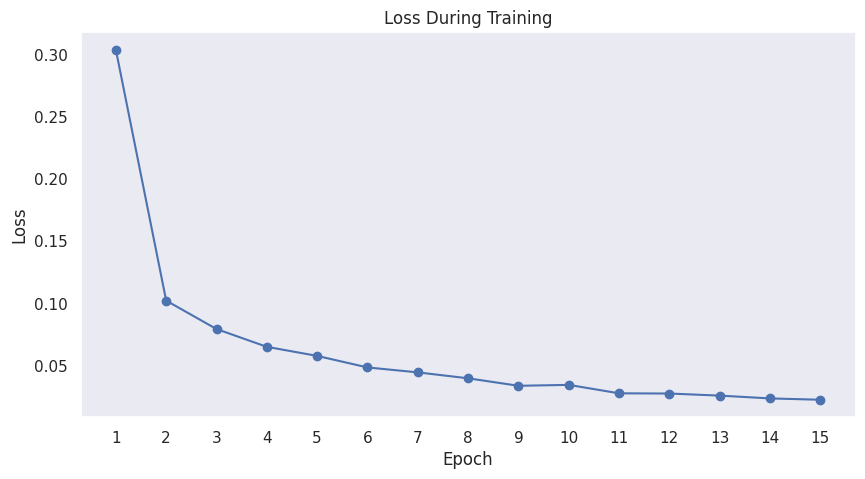

In [199]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), losses, marker='o')
plt.title('Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(1, num_epochs + 1))
plt.grid()
plt.show()

In [200]:
model.eval()
all_labels = []
all_predictions = []

In [201]:
with torch.no_grad():  
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)  
        all_labels.extend(labels.numpy())  
        all_predictions.extend(predicted.numpy())

In [202]:
accuracy = sum(np.array(all_predictions) == np.array(all_labels)) / len(all_labels)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 98.43%


In [203]:
report = classification_report(all_labels, all_predictions, digits=4)
print(report)

              precision    recall  f1-score   support

           0     0.9808    0.9929    0.9868       980
           1     0.9894    0.9894    0.9894      1135
           2     0.9790    0.9942    0.9865      1032
           3     0.9794    0.9881    0.9837      1010
           4     0.9907    0.9807    0.9857       982
           5     0.9888    0.9865    0.9877       892
           6     0.9915    0.9791    0.9853       958
           7     0.9863    0.9835    0.9849      1028
           8     0.9824    0.9743    0.9784       974
           9     0.9752    0.9732    0.9742      1009

    accuracy                         0.9843     10000
   macro avg     0.9844    0.9842    0.9843     10000
weighted avg     0.9843    0.9843    0.9843     10000



In [204]:
cm = confusion_matrix(all_labels, all_predictions)

In [205]:
def confusion_matrix_visualisation(cm):
    plt.figure(figsize=(8, 5))
    sns.heatmap(cm, square=True, annot=True, cmap='BuPu')
    plt.title('Confusion Matrix')
    plt.ylabel('Действительный класс')
    plt.xlabel('Предсказанный класс')

    plt.tight_layout()
    plt.show()

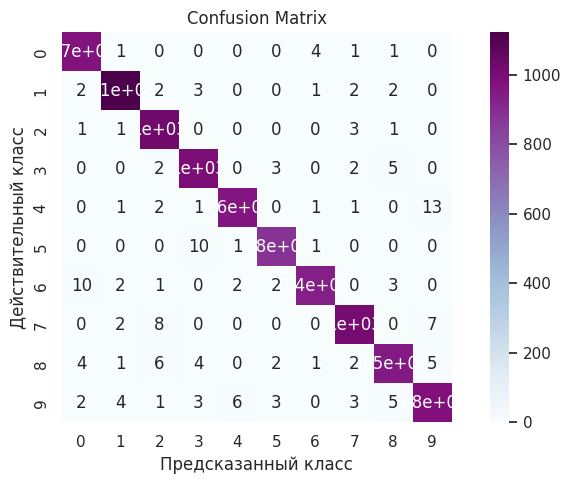

In [206]:
confusion_matrix_visualisation(cm)

Выводы: работает очень быстро, при этом получаем хорошую точность - не хуже svc и сильно быстрее!

SVC 
 - Accuracy Score with HOG features: 0.9867857142857143
 - Fit Time 153.67591786384583 seconds

соберём всё в класс

In [211]:
class SimplePerceptron(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimplePerceptron, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)  
        self.fc2 = nn.Linear(hidden_size, hidden_size)  
        self.fc3 = nn.Linear(hidden_size, num_classes)  
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        x = self.dropout(torch.relu(self.fc1(x))) 
        x = self.dropout(torch.relu(self.fc2(x)))  
        x = self.fc3(x)  
        return x
    
    def fit(self, train_loader, num_epochs, learning_rate):
        criterion = nn.CrossEntropyLoss() 
        optimizer = optim.Adam(self.parameters(), lr=learning_rate)  

        losses = []

        start_time = time.time()
        for epoch in range(num_epochs):
            epoch_loss = 0.0
            for images, labels in train_loader:
                optimizer.zero_grad()  
                outputs = self(images)  
                loss = criterion(outputs, labels) 
                loss.backward() 
                optimizer.step() 
                epoch_loss += loss.item()
                
            avg_epoch_loss = epoch_loss / len(train_loader)
            losses.append(avg_epoch_loss) 
            print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_epoch_loss:.4f}')
        
        total_time = time.time() - start_time
        print(f'Total fitting time: {total_time:.2f} seconds')
        
        return losses  

    def evaluate(self, test_loader):
        self.eval()  
        all_labels = []
        all_predictions = []

        with torch.no_grad():  
            for images, labels in test_loader:
                outputs = self(images)
                _, predicted = torch.max(outputs.data, 1)  
                all_labels.extend(labels.numpy())  
                all_predictions.extend(predicted.numpy())  

        accuracy = sum(np.array(all_predictions) == np.array(all_labels)) / len(all_labels)
        print(f'Accuracy: {accuracy * 100:.2f}%')

        report = classification_report(all_labels, all_predictions, digits=4)
        print(report)

        cm = confusion_matrix(all_labels, all_predictions)
        confusion_matrix_visualisation(cm)

In [208]:
model = SimplePerceptron(input_size, hidden_size, num_classes)
start_time = time.time()
losses = model.fit(train_loader, num_epochs, learning_rate)
total_time = time.time() - start_time
print(f'Total fitting time: {total_time:.2f} seconds')

Epoch [1/15], Loss: 0.3010
Epoch [2/15], Loss: 0.0998
Epoch [3/15], Loss: 0.0788
Epoch [4/15], Loss: 0.0645
Epoch [5/15], Loss: 0.0566
Epoch [6/15], Loss: 0.0490
Epoch [7/15], Loss: 0.0429
Epoch [8/15], Loss: 0.0374
Epoch [9/15], Loss: 0.0348
Epoch [10/15], Loss: 0.0333
Epoch [11/15], Loss: 0.0309
Epoch [12/15], Loss: 0.0265
Epoch [13/15], Loss: 0.0257
Epoch [14/15], Loss: 0.0252
Epoch [15/15], Loss: 0.0249
Total fitting time: 28.97 seconds
Total fitting time: 28.97 seconds


Accuracy: 98.64%
              precision    recall  f1-score   support

           0     0.9838    0.9918    0.9878       980
           1     0.9894    0.9894    0.9894      1135
           2     0.9884    0.9922    0.9903      1032
           3     0.9842    0.9871    0.9857      1010
           4     0.9898    0.9888    0.9893       982
           5     0.9910    0.9877    0.9893       892
           6     0.9803    0.9864    0.9834       958
           7     0.9902    0.9835    0.9868      1028
           8     0.9835    0.9805    0.9820       974
           9     0.9830    0.9762    0.9796      1009

    accuracy                         0.9864     10000
   macro avg     0.9864    0.9864    0.9864     10000
weighted avg     0.9864    0.9864    0.9864     10000



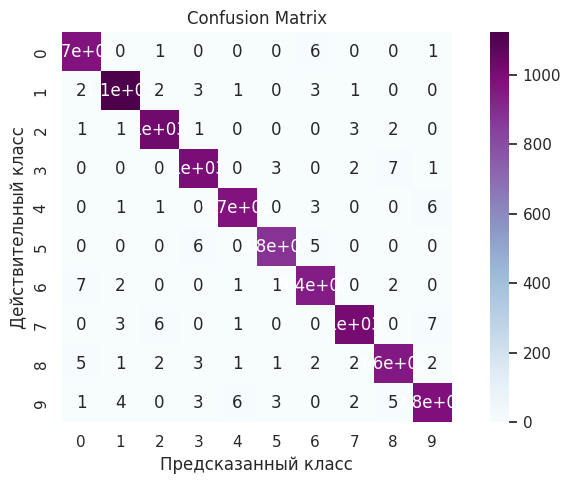

In [209]:
model.evaluate(test_loader)

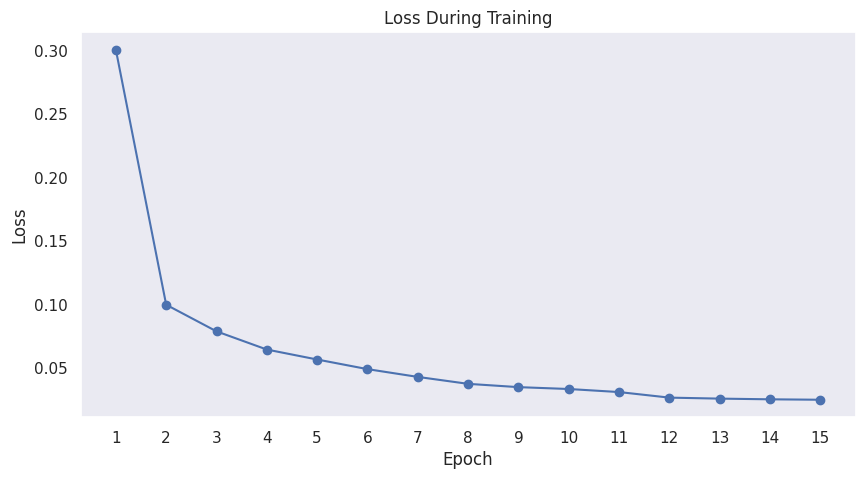

In [210]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), losses, marker='o')
plt.title('Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(1, num_epochs + 1))
plt.grid()
plt.show()